# K-Means Clustering Demo (Custom Implementation)

## Dataset: Synthetic Blobs

We will use the `make_blobs` dataset from scikit-learn to demonstrate our custom K-Means implementation.

This dataset is ideal because:
- It generates well-separated clusters
- We know the true labels (for evaluation only)
- It visually demonstrates clustering behavior clearly

We will:
1. Generate data
2. Visualize raw points
3. Fit our custom K-Means model
4. Visualize clusters
5. Compare with true labels

In [22]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic dataset
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

print("Dataset shape:", X.shape)

Dataset shape: (300, 2)


## Visualizing the Raw Data

Before applying K-Means, we visualize the dataset to understand its structure.

Since this is a synthetic dataset, clusters are present but unlabeled.

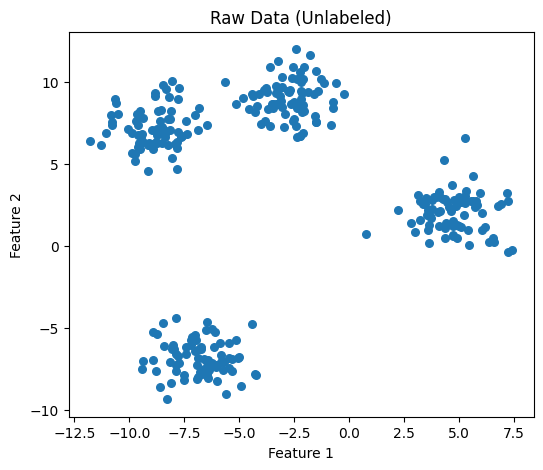

In [23]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Raw Data (Unlabeled)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Fitting Custom K-Means

We now apply our custom K-Means implementation.

### Key idea:
- Randomly initialize centroids
- Assign points to nearest centroid
- Update centroids using cluster means
- Repeat until convergence

In [24]:
from rice_ml import KMeans 

# results = []

# for i in range(20):
#     model = KMeans(K=4, max_iters=100, random_state=i)
#     model.fit(X)
#     print(f"centroids on iter {i}: {model.centroids}")

kmeans = KMeans(K=4, max_iters=100, tol=1e-4, random_state=5)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.centroids

print("Final centroids:\n", centroids)

Final centroids:
 [[-6.82289702 -6.82052706]
 [-8.88062107  7.14479553]
 [-2.7332785   8.96731218]
 [ 4.73387011  2.05552217]]


## Cluster Visualization

Each color represents a cluster assigned by K-Means.

Red stars indicate the final centroid positions.

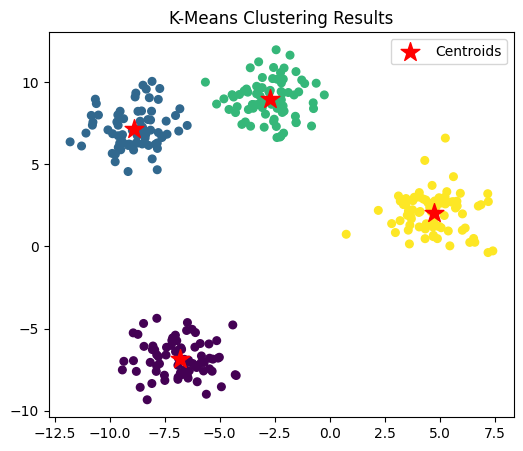

In [25]:
plt.figure(figsize=(6, 5))

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    marker="*",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.legend()
plt.show()

## Comparing with True Labels

Although K-Means is unsupervised, we can compare its output with the true labels
(from the dataset generator) to evaluate performance visually.

Note: These labels are NOT used during training.

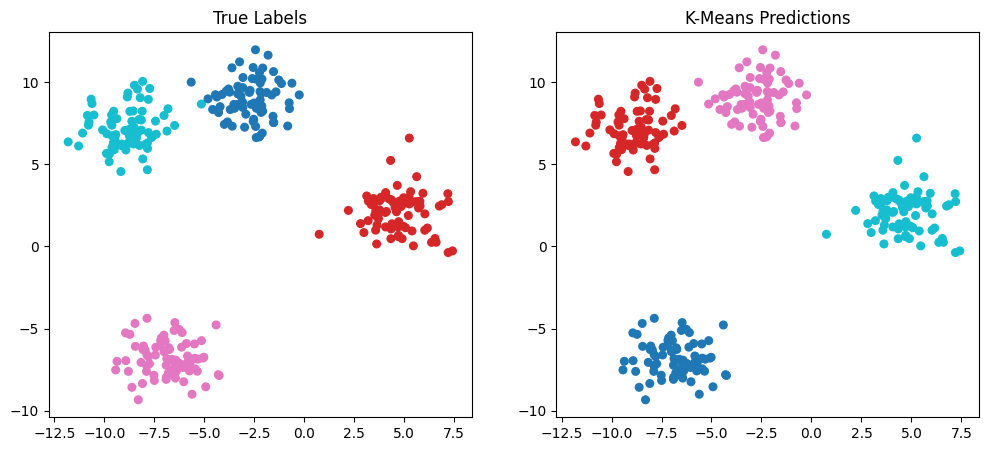

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=30)
plt.title("True Labels")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=30)
plt.title("K-Means Predictions")

plt.show()

## Key Takeaways

- K-Means works well when clusters are spherical and well-separated
- Results depend on centroid initialization
- The algorithm minimizes within-cluster variance iteratively
- Even without labels, meaningful structure is recovered